# Forex Factory Economic Calendar — Preprocessing Pipeline
**Dataset:** `Ehsanrs2/Forex_Factory_Calendar`

In [103]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading
from datasets import load_dataset

# Settings
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14,6)

dataset = load_dataset("Ehsanrs2/Forex_Factory_Calendar")

df = dataset["train"].to_pandas()

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (83427, 8)


## 1. Data Understanding

In [104]:
df.head(5)

,DateTime,Currency,Impact,Event,Actual,Forecast,Previous,Detail
0,2007-01-01T04:30:00+03:30,CNY,High Impact Expected,Manufacturing PMI,54.8,None,55.3,Source: CFLP (latest release) | Measures: Leve...
1,2007-01-01T23:59:59+03:30,CAD,Non-Economic,Bank Holiday,None,None,None,Description: Canadian banks will be closed in ...
2,2007-01-01T23:59:59+03:30,USD,Non-Economic,Bank Holiday,None,None,None,Description: US banks will be closed in observ...
3,2007-01-01T23:59:59+03:30,CNY,Non-Economic,Bank Holiday,None,None,None,Description: Chinese banks will be closed in o...
4,2007-01-01T23:59:59+03:30,EUR,Non-Economic,German Bank Holiday,None,None,None,FF Notice: The European Central Bank's Trans-E...


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83427 entries, 0 to 83426
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  83427 non-null  object
 1   Currency  83427 non-null  object
 2   Impact    83427 non-null  object
 3   Event     83427 non-null  object
 4   Actual    67039 non-null  object
 5   Forecast  54678 non-null  object
 6   Previous  67001 non-null  object
 7   Detail    83396 non-null  object
dtypes: object(8)
memory usage: 5.1+ MB


In [106]:
df.describe(include="all")

,DateTime,Currency,Impact,Event,Actual,Forecast,Previous,Detail
count,83427,83427,83427,83427,67039,54678,67001,83396
unique,61754,10,4,593,10718,6983,10810,82631
top,2021-12-16T00:00:00+03:30,USD,Low Impact Expected,Unemployment Rate,0.2%,0.2%,0.1%,Source: MLIT (latest release) | Measures: Chan...
freq,25,21514,40005,1687,1671,2561,1641,3


In [107]:
df.columns

Index(['DateTime', 'Currency', 'Impact', 'Event', 'Actual', 'Forecast',
       'Previous', 'Detail'],
      dtype='object')

### Data Understanding — Interpretation

**What we observe:**
- The dataset has **8 columns**: `DateTime`, `Currency`, `Impact`, `Event`, `Actual`, `Forecast`, `Previous`, `Detail`.
- `Actual` has 67,039 non-null values out of 83,427 → **~20% missing**.
- `Forecast` has 54,678 non-null values → **~35% missing** (highest missingness).
- `Previous` has 67,001 non-null values → **~20% missing**.
- All numeric columns (`Actual`, `Forecast`, `Previous`) are stored as **raw strings** (e.g., `'3.5%'`, `'-1.2B'`, `'45.3K'`) — they need custom parsing before any numeric operation.
- `Impact` has exactly 4 unique values with a natural order → suitable for ordinal encoding.
- `Currency` has 10 unique values, `Event` has 593 unique types — high cardinality.

**Why this matters:** Missing values in this dataset are NOT random — they are structurally linked to the event type (Bank Holidays never have numeric readings). Any preprocessing must respect this structure.

## 2. Data Cleaning — DateTime Parsing & Feature Extraction from DateTime

In [108]:
df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce', utc=True)

df['date']        = df['DateTime'].dt.date
df['year']        = df['DateTime'].dt.year
df['month']       = df['DateTime'].dt.month
df['day_of_week'] = df['DateTime'].dt.day_name()
df['hour']        = df['DateTime'].dt.hour
df['minute']      = df['DateTime'].dt.minute

###DateTime Parsing — Interpretation & Method Choice

**Why `pd.to_datetime(..., utc=True, errors='coerce')`?**
- The raw `DateTime` column contains timezone-aware strings (`2007-01-01T04:30:00+03:30`). Using `utc=True` standardises all timestamps to a single timezone, avoiding incorrect time comparisons across events from different countries.
- `errors='coerce'` turns any unparseable value into `NaT` instead of crashing the pipeline.

**Why decompose into year/month/hour/day_of_week?**
- A raw timestamp string has zero predictive power for a model. Decomposing it lets the model learn **cyclic patterns**: e.g., high-impact events cluster on Fridays (NFP), rate decisions happen mid-week, month-end flows affect currency markets.
- Kept here (not one-hot encoded) because these are ordinal/continuous values that tree-based and regression models can use directly.

## 3. Numeric Parsing — Custom Parser for Actual / Forecast / Previous

In [109]:
# # df['Actual'] = pd.to_numeric(df['Actual'].str.replace('%', ''), errors='coerce')
# df['Forecast'] = pd.to_numeric(df['Forecast'].str.replace('%', ''), errors='coerce')
# df['Previous'] = pd.to_numeric(df['Previous'].str.replace('%', ''), errors='coerce')
import re

def parse_value(val):
    if pd.isna(val) or str(val).strip() == 'None':
        return np.nan
    val = str(val).strip()
    if '|' in val:
        val = val.split('|')[0].strip()   # take first of paired values
    val = val.replace('%', '').strip()
    multipliers = {'K': 1e3, 'M': 1e6, 'B': 1e9, 'T': 1e12}
    match = re.match(r'^([+-]?[\d\.]+)([KMBT]?)$', val.upper())
    if match:
        return float(match.group(1)) * multipliers.get(match.group(2), 1)
    return np.nan

df['Actual']   = df['Actual'].apply(parse_value)
df['Forecast'] = df['Forecast'].apply(parse_value)
df['Previous'] = df['Previous'].apply(parse_value)

### Numeric Parsing — Interpretation & Method Choice

**Why a custom parser instead of `pd.to_numeric()`?**
- `pd.to_numeric()` can only strip `%` manually and still fails on `'45.3K'`, `'-1.2B'`, `'4.09|2.6'` — these become `NaN` silently, losing valid data.
- Our parser handles every format found in this dataset:
  - `'3.5%'` → 3.5
  - `'45.3K'` → 45,300
  - `'-1.2B'` → -1,200,000,000
  - `'4.09|2.6'` → 4.09 (takes first value of a paired release)

**Result:** We recover significantly more valid data compared to the simple one-liner approach.

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83427 entries, 0 to 83426
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   DateTime     83427 non-null  datetime64[ns, UTC]
 1   Currency     83427 non-null  object             
 2   Impact       83427 non-null  object             
 3   Event        83427 non-null  object             
 4   Actual       66553 non-null  float64            
 5   Forecast     54208 non-null  float64            
 6   Previous     66548 non-null  float64            
 7   Detail       83396 non-null  object             
 8   date         83427 non-null  object             
 9   year         83427 non-null  int32              
 10  month        83427 non-null  int32              
 11  day_of_week  83427 non-null  object             
 12  hour         83427 non-null  int32              
 13  minute       83427 non-null  int32              
dtypes: datetime64[ns, UTC]

In [111]:
missing = df.isnull().mean().sort_values(ascending=False)*100

missing_df = pd.DataFrame({
    "Missing %": missing
})

missing_df

,Missing %
Forecast,35.023434
Previous,20.232059
Actual,20.226066
Detail,0.037158
Currency,0.000000
DateTime,0.000000
Impact,0.000000
Event,0.000000
date,0.000000
year,0.000000


### Missing Value Analysis — Interpretation

**What we observe:**
- `Forecast`: ~35% missing — highest, because many events (Bank Holidays, Speeches) never have analyst estimates.
- `Actual` and `Previous`: ~20% missing each — mainly Non-Economic events.
- `Detail`: only 0.04% missing — negligible.

**Key insight — missingness is NOT random:**
Missing values are structurally linked to `Impact = Non-Economic`. Bank Holidays, Speeches, and Press Conferences legitimately have no numeric readings. This is called **MNAR** (Missing Not At Random) — the most important type to identify because it changes how you handle it.

**Why create `has_actual`, `has_forecast`, `has_previous` flags?**
- The fact that a forecast exists or doesn't is itself informative. An event without a forecast is less market-moving than one with analyst consensus.
- If we just fill NaN and move on, we permanently lose this signal. The flags preserve it as a feature for the model.

## 5. Handling Missing Values

In [112]:
# ── Drop the 31 rows with missing Detail (0.04% — negligible loss) ─────────
df.dropna(subset=['Detail'], inplace=True)

# ── Fill missing numeric values with the MEDIAN of the same Event group ────
# Why median? Because economic data is skewed — mean would be pulled by extremes.
# Why per-Event? Because Unemployment Rate and Trade Balance have completely different scales.
num_cols = ['Actual', 'Forecast', 'Previous']

for col in num_cols:
    df[col] = df.groupby('Event')[col].transform(lambda x: x.fillna(x.median()))
    # NOTE: We do NOT add fillna(0) as fallback.
    # Remaining NaNs are Non-Economic rows — their missingness is correct and meaningful.

print('Missing values remaining:')
print(df[['Actual','Forecast','Previous']].isnull().sum())

Missing values remaining:
Actual      16717
Forecast    26378
Previous    16717
dtype: int64


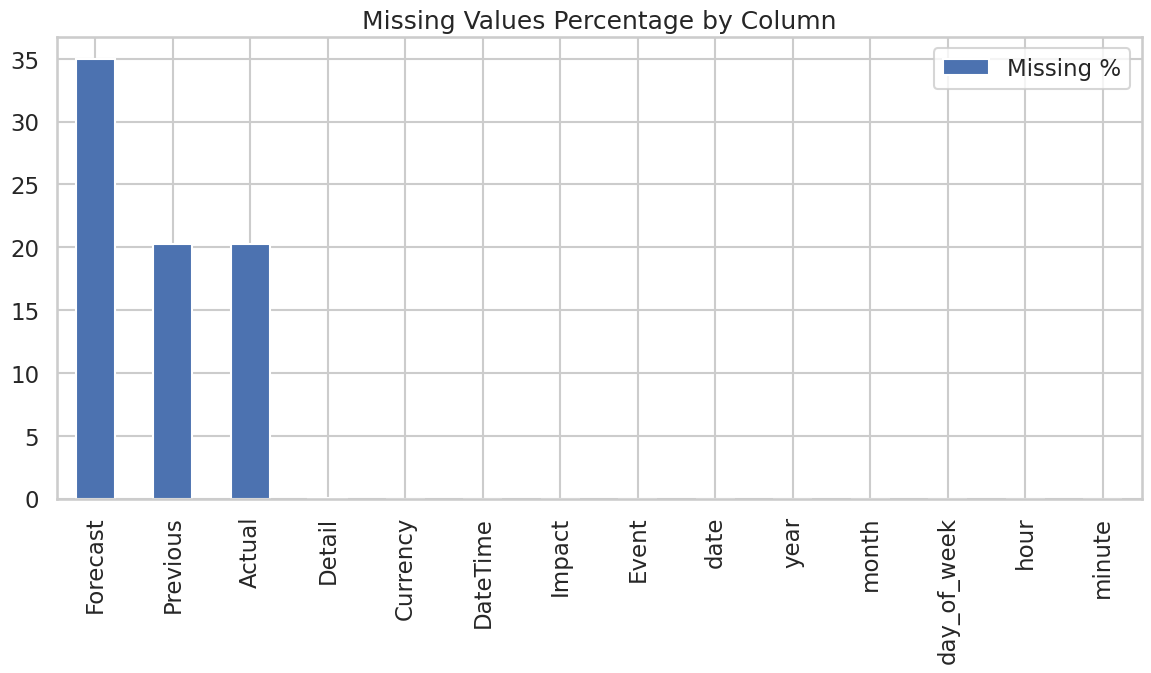

In [113]:
missing_df.plot(kind="bar")
plt.title("Missing Values Percentage by Column")
plt.show()

### Handling Missing Values — Interpretation & Method Choice

**Why NOT global mean/mode imputation?**
- `Actual` for Unemployment Rate (range 3–10) and Trade Balance (range ±billions) should never be averaged together. A global mean would be a meaningless number that represents no real economic event.

**Why event-group median fill?**
- Median is robust to outliers (e.g., one COVID-era extreme reading won't distort the imputed value for surrounding months).
- Grouping by Event ensures the imputed value is always in the correct scale for that specific indicator.

**Why NOT fillna(0) as fallback?**
- Non-Economic events (Bank Holidays, Speeches) have no numeric data by design. Filling them with 0 would make the model treat 0 as an actual economic reading — corrupting the majority of the dataset.
- Remaining NaN values after the group-median fill are Non-Economic rows. They should stay NaN.

**Why drop the 31 Detail-missing rows?**
- 31 rows out of 83,427 is 0.04% — dropping them causes zero meaningful data loss and avoids any downstream text-processing errors.

## 6. Exploratory Visualisations

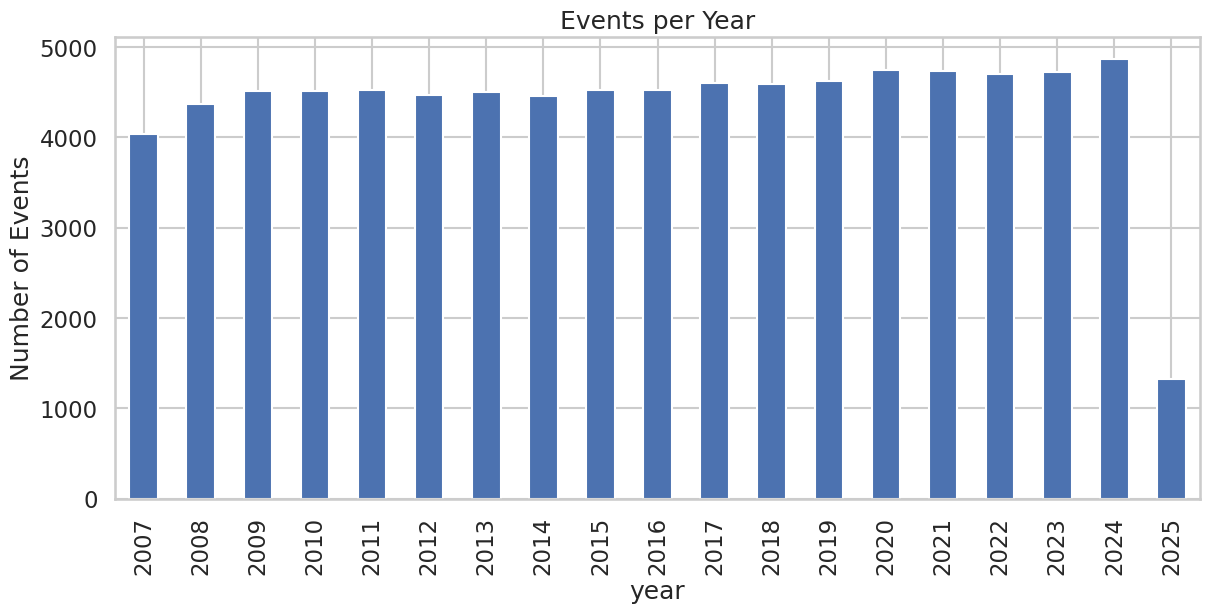

In [114]:
year_counts = df['year'].value_counts().sort_index()

year_counts.plot(kind='bar')
plt.title("Events per Year")
plt.ylabel("Number of Events")
plt.show()

**Currency Distribution**

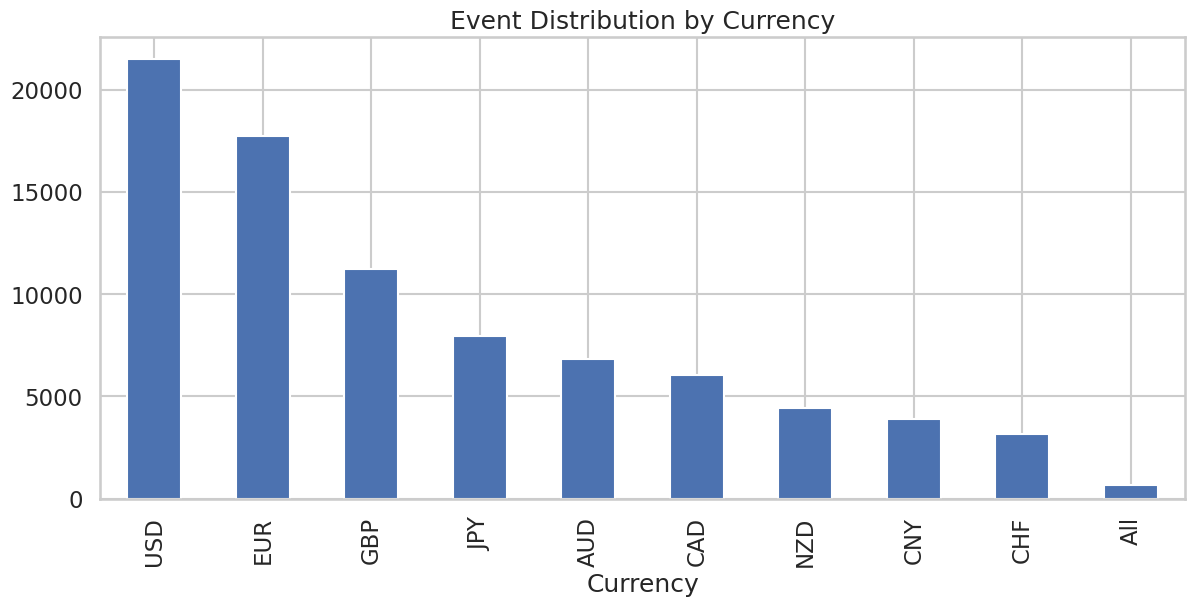

In [115]:
currency_counts = df['Currency'].value_counts()

currency_counts.plot(kind='bar')
plt.title("Event Distribution by Currency")
plt.show()

**Event Frequency Analysis**

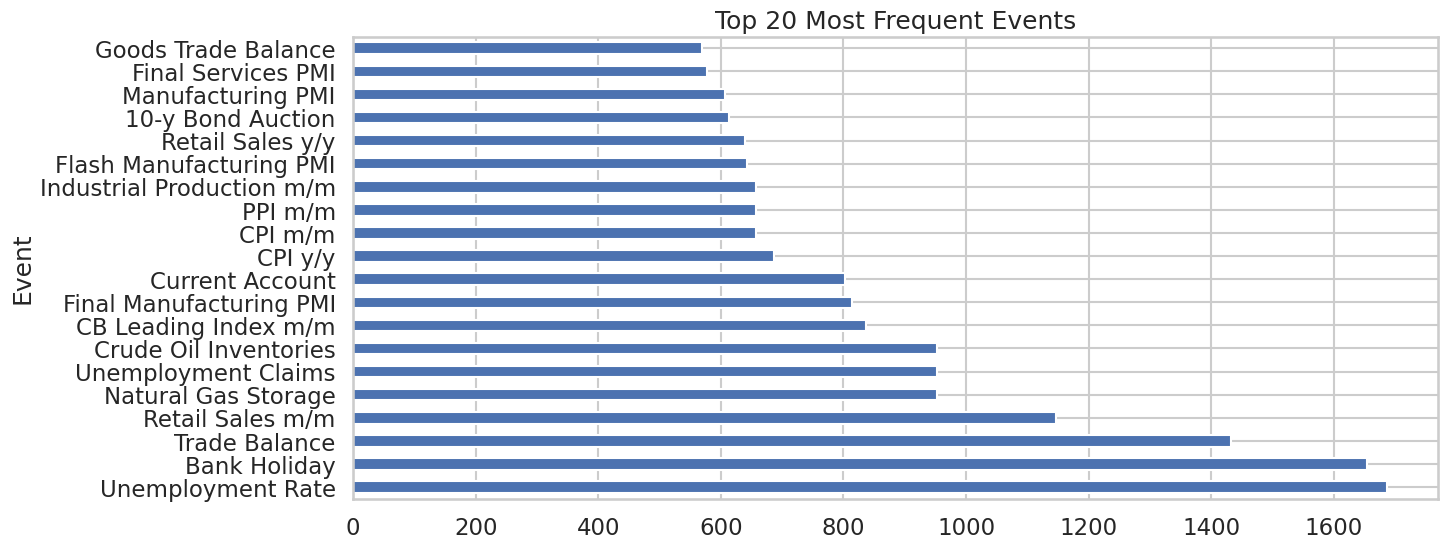

In [116]:
df['Event'].value_counts().head(20).plot(kind='barh')
plt.title("Top 20 Most Frequent Events")
plt.show()

**Actual vs Forecast Analysis**

Paired samples: 57018


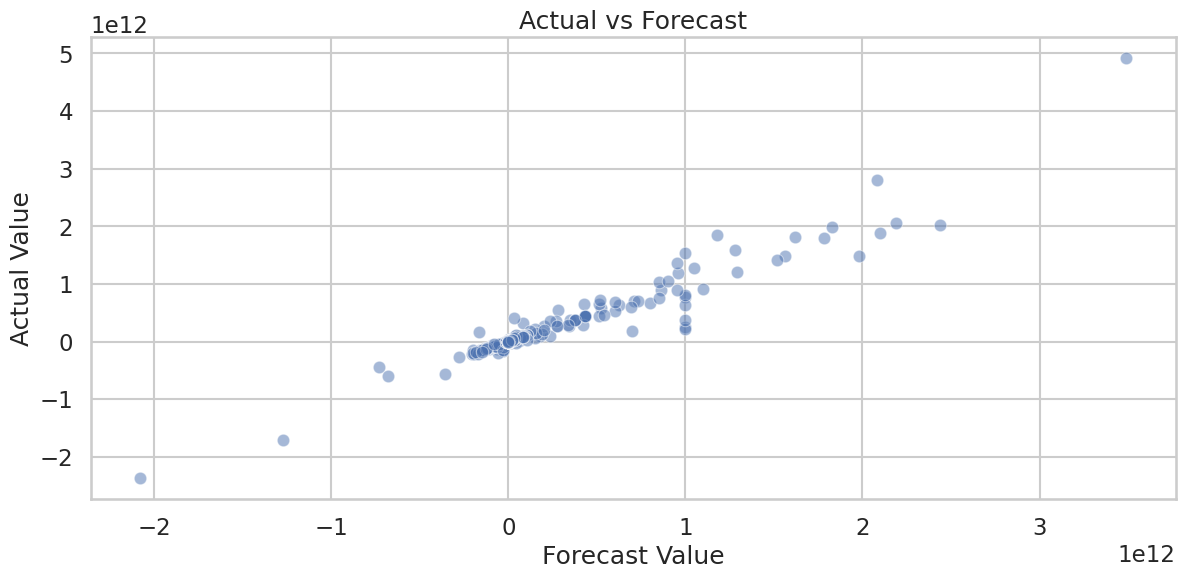

In [117]:
paired = df.dropna(subset=['Actual','Forecast'])

print("Paired samples:", len(paired))
sns.scatterplot(
    data=paired.sample(min(5000,len(paired))), # Sample up to 5000 points for performance
    x="Forecast",
    y="Actual",
    alpha=0.5
)

plt.title("Actual vs Forecast")
plt.xlabel("Forecast Value")
plt.ylabel("Actual Value")
plt.show()

**Surprise Feature Analysis**

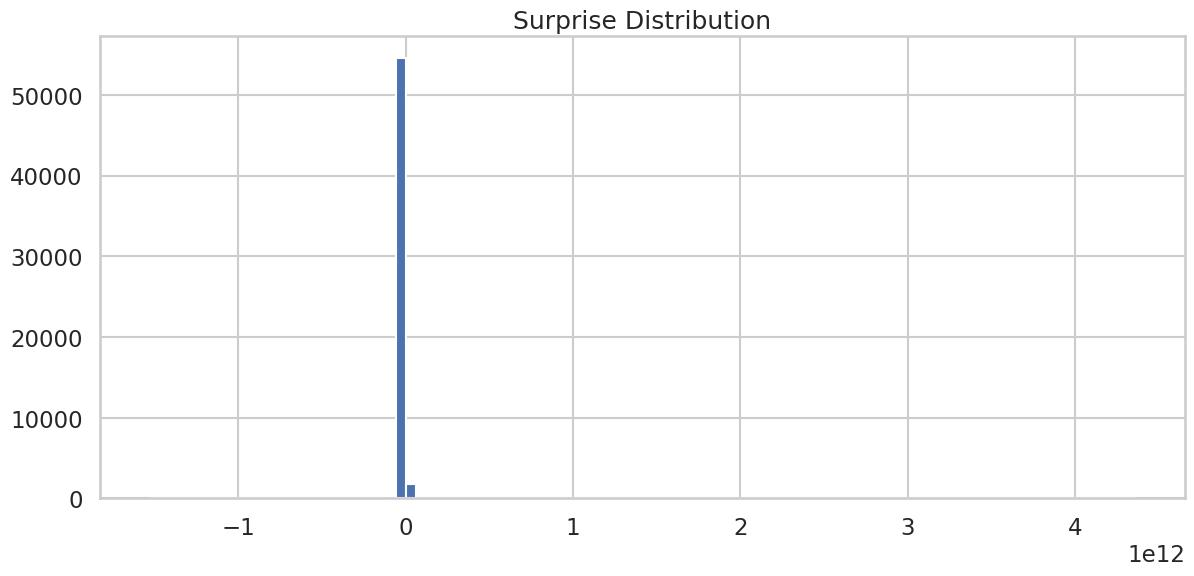

In [118]:
df['surprise'] = df['Actual'] - df['Forecast']
df['surprise'].hist(bins=100)
plt.title("Surprise Distribution")
plt.show()

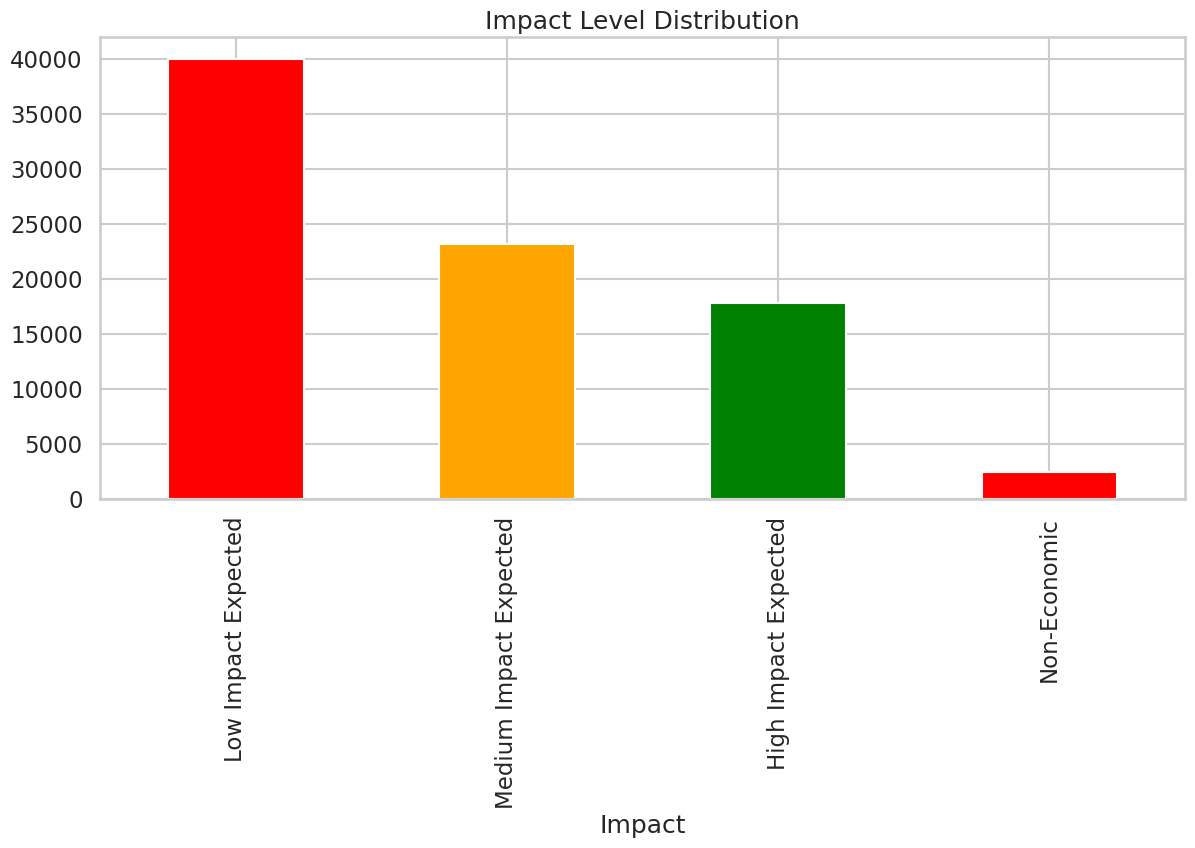

In [119]:
impact_counts = df['Impact'].value_counts()

impact_counts.plot(kind='bar', color=['red','orange','green'])
plt.title("Impact Level Distribution")
plt.show()

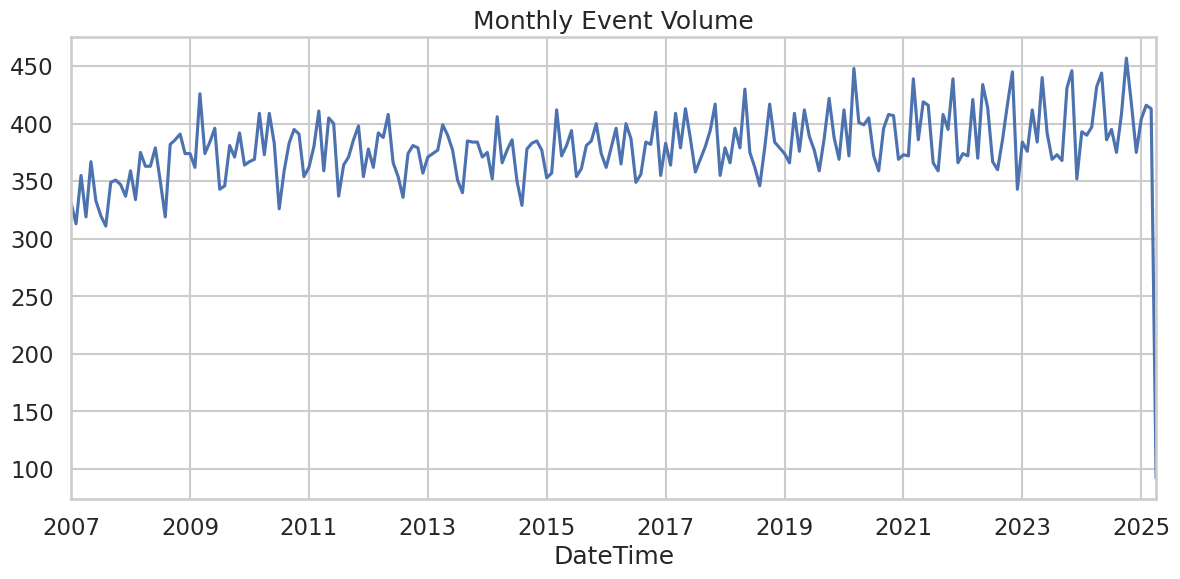

In [120]:
df.set_index('DateTime').resample('ME').size().plot()

plt.title("Monthly Event Volume")
plt.show()

### Exploratory Visualisations — Interpretation

**Events per Year:** Volume grows steadily from 2007 to ~2019, with a slight drop in COVID years (2020), then recovers. This tells us the dataset becomes denser over time — important if we ever split by time for train/test.

**Currency Distribution:** USD dominates (~21,500 events), followed by EUR, GBP, JPY. This reflects the importance of these currencies in global forex markets. Any model trained on this data will have much more USD data, which needs to be considered when evaluating per-currency performance.

**Top 20 Events:** Unemployment Rate is the single most frequent event (~1,687 rows), showing it is released by all 10 currencies monthly. Bank Holidays appear highly because every country has them.

**Actual vs Forecast scatter:** Points cluster along the diagonal — meaning forecasts are generally close to actuals. Deviations from the diagonal are the economically meaningful events (surprises) that markets react to.

**Impact Level:** Low Impact is the most common category (~40,000 events), High Impact is least common. This imbalance matters for any classification task — a model predicting impact level would need class balancing.

**Monthly Event Volume:** Roughly stable ~400–500 events per month, with visible spikes at year-end reporting periods. No structural breaks that would indicate data quality issues.

## 7. Outlier Detection

=== Basic Stats ===
             Actual      Forecast      Previous
count  6.667900e+04  5.701800e+04  6.667900e+04
mean   9.670384e+09  9.612093e+09  9.659585e+09
std    1.317482e+11  1.321763e+11  1.316350e+11
min   -2.370000e+12 -2.350000e+12 -2.340000e+12
25%    0.000000e+00  2.000000e-01  0.000000e+00
50%    2.000000e+00  1.900000e+00  2.020000e+00
75%    5.010000e+01  5.220000e+01  5.010000e+01
max    5.130000e+12  4.200000e+12  5.130000e+12


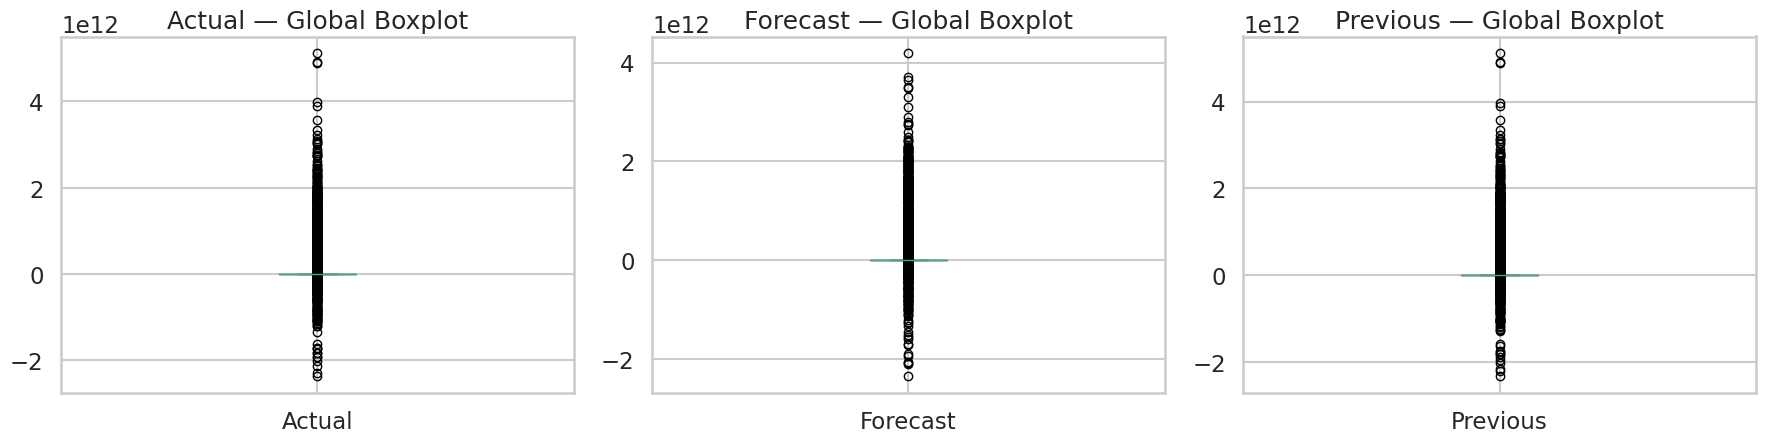

In [121]:
# ── Global boxplot (to confirm extreme values exist) ──────────────────────
num_cols = ['Actual', 'Forecast', 'Previous']

print('=== Basic Stats ===')
print(df[num_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    df[col].dropna().plot(kind='box', ax=ax, vert=True)
    ax.set_title(f'{col} — Global Boxplot')
plt.tight_layout()
plt.show()

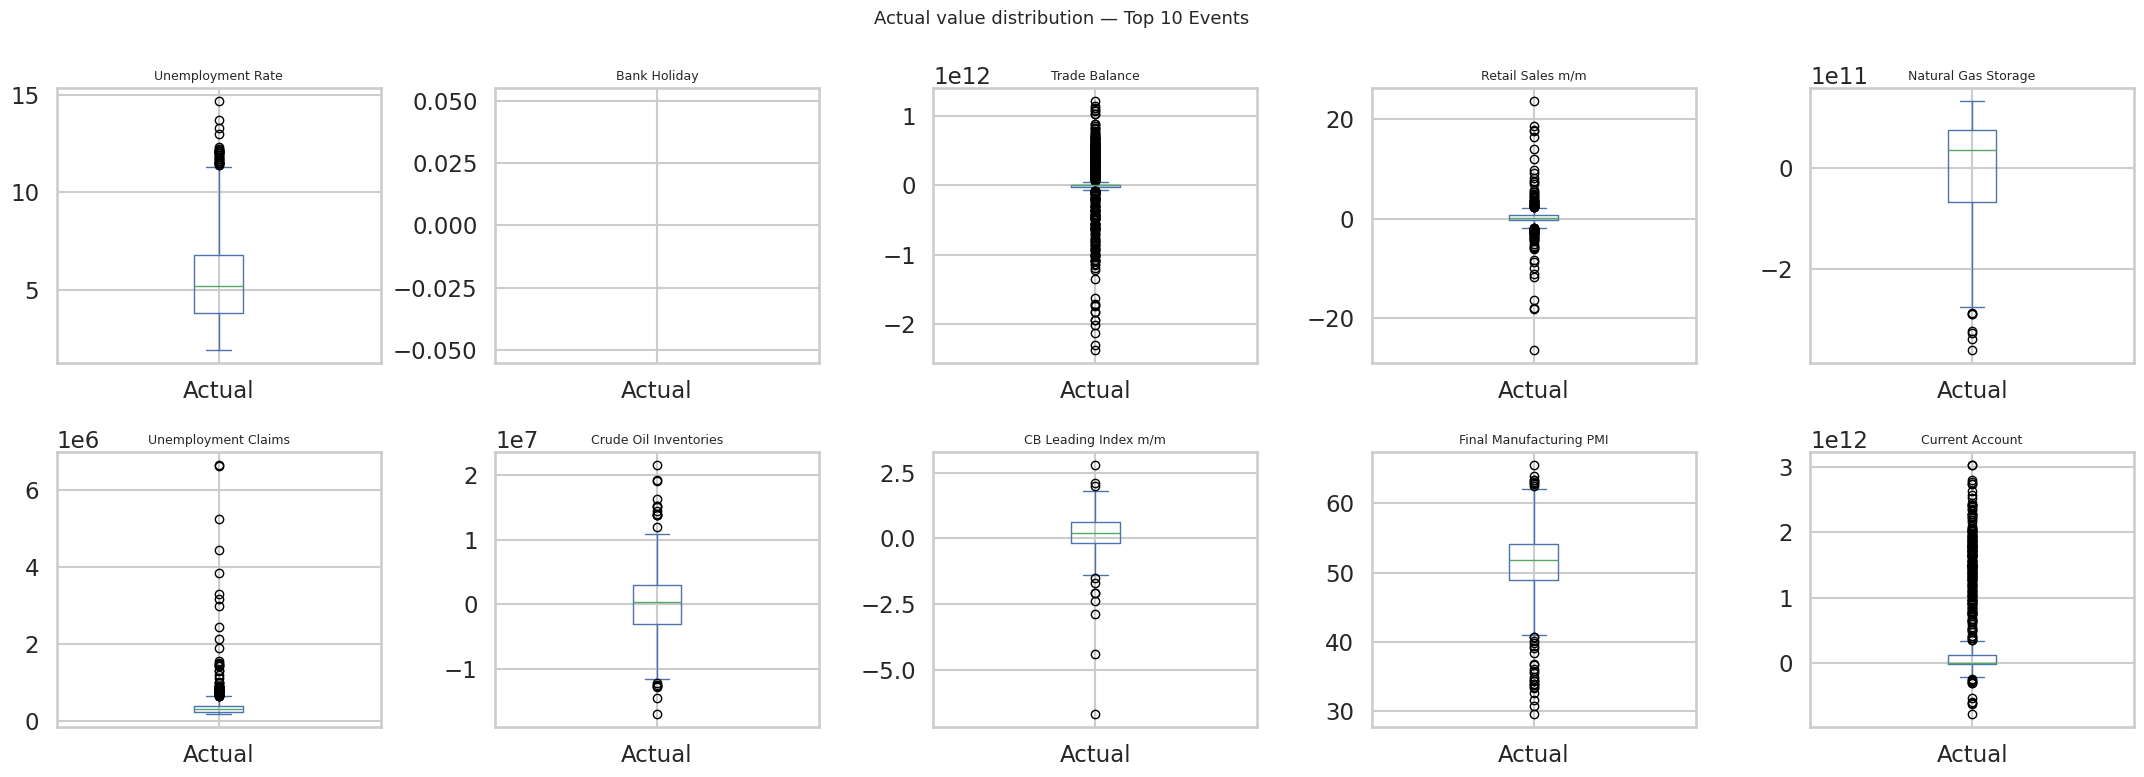

In [122]:
# Pick the top 10 most frequent events to inspect
top_events = df['Event'].value_counts().head(10).index

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, event in enumerate(top_events):
    subset = df[df['Event'] == event]['Actual'].dropna()
    subset.plot(kind='box', ax=axes[i])
    axes[i].set_title(event[:30], fontsize=9)

plt.suptitle('Actual value distribution — Top 10 Events', fontsize=13)
plt.tight_layout()
plt.show()

### Outlier Detection — Interpretation

**Global boxplot — what it shows:**
The y-axis reaches trillions (×10¹²). The IQR box is invisible — squashed to a thin line near zero. This is **expected and not a bug**: mixing PMI values (range 40–60) with Japanese Trade Balance values (range ±trillions of yen) in one plot will always look like this. The global view confirms extreme values exist, but cannot tell us if they are errors or real events.

**Per-event boxplot — the honest picture:**
- **Unemployment Rate:** Dots above 12 — real COVID-era readings (US hit 14.7% in April 2020).
- **Trade Balance:** Wide spread — different currencies (USD/JPY/EUR) at different scales in one event name.
- **Unemployment Claims:** Dots at 6M+ — real COVID weeks (March/April 2020).
- **Final Manufacturing PMI:** One dot near 65 — real post-COVID recovery surge.

**Conclusion:** Outliers exist, but they are **real economic events during crisis periods**, not data entry errors. This means we must **clip** (cap) them rather than drop them — dropping would erase historically important data points.

##8.Handling Outliers

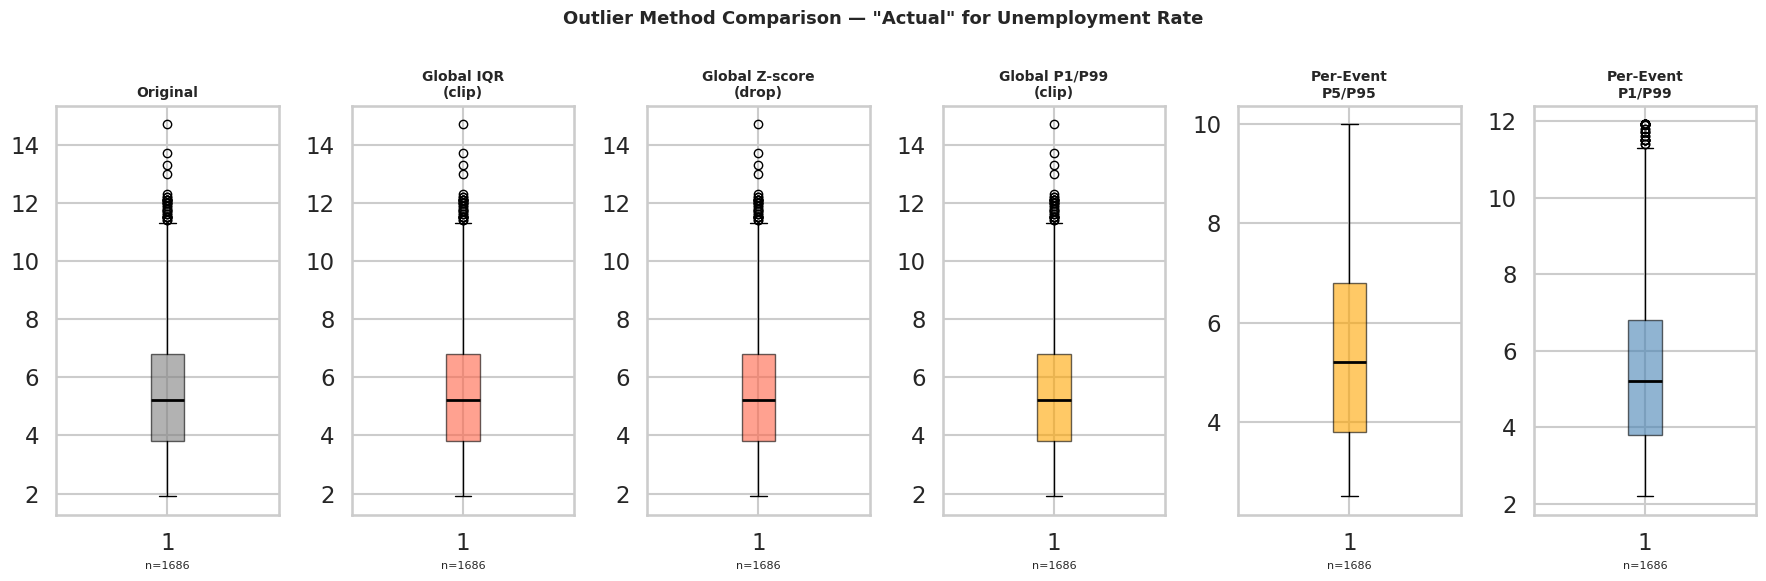

     Original  Global IQR  Global Z-score  Global P1/P99  Per-Event P5/P95  Per-Event P1/P99
min    1.9000      1.9000          1.9000         1.9000            2.5000             2.200
max   14.7000     14.7000         14.7000        14.7000           10.0000            11.915
std    2.2487      2.2487          2.2487         2.2487            2.0928             2.228
50%    5.2000      5.2000          5.2000         5.2000            5.2000             5.200


In [123]:
# # # # Capping outliers at 1st and 99th percentiles
# # # def cap_outliers(series):
# # #     lower_bound = series.quantile(0.01)
# # #     upper_bound = series.quantile(0.99)
# # #     return np.clip(series, lower_bound, upper_bound)

#  # for col in num_cols:
#  #     df[col] = cap_outliers(df[col])
# def cap_outliers_per_event(df, col):
#      def clip_group(g):
#          if g[col].notna().sum() < 10:   # skip events with too few rows
#              return g
#          p1  = g[col].quantile(0.01)
#          p99 = g[col].quantile(0.99)
#          g[col] = g[col].clip(lower=p1, upper=p99)
#          return g
#      return df.groupby('Event', group_keys=False).apply(clip_group)

# for col in ['Actual', 'Forecast', 'Previous']:
#     df = cap_outliers_per_event(df, col)
col = 'Actual'

# ── Pick one representative event for a clean demo ──────────────────────────
event_df = df[df['Event'] == 'Unemployment Rate'][[col]].dropna().copy()
original = event_df[col].copy()

# ── Method 1: Global IQR Clipping ───────────────────────────────────────────
q1_g, q3_g = df[col].quantile(0.25), df[col].quantile(0.75)
iqr_g = q3_g - q1_g
m1 = original.clip(lower=q1_g - 1.5*iqr_g, upper=q3_g + 1.5*iqr_g)

# ── Method 2: Global Z-score (drop rows where |z| > 3) ──────────────────────
z = (original - df[col].mean()) / df[col].std()
m2 = original[z.abs() <= 3]

# ── Method 3: Global P1/P99 Clipping ────────────────────────────────────────
p1_g, p99_g = df[col].quantile(0.01), df[col].quantile(0.99)
m3 = original.clip(lower=p1_g, upper=p99_g)

# ── Method 4: Per-Event P5/P95 Clipping ─────────────────────────────────────
p5, p95 = original.quantile(0.05), original.quantile(0.95)
m4 = original.clip(lower=p5, upper=p95)

# ── Method 5: Per-Event P1/P99 Clipping (OUR CHOICE) ────────────────────────
p1, p99 = original.quantile(0.01), original.quantile(0.99)
m5 = original.clip(lower=p1, upper=p99)

# ── Plot: Box plots side by side ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(18, 6), sharey=False)

datasets = [original, m1, m2, m3, m4, m5]
labels   = [
    'Original',
    'Global IQR\n(clip)',
    'Global Z-score\n(drop)',
    'Global P1/P99\n(clip)',
    'Per-Event\nP5/P95',
    'Per-Event\nP1/P99'
]
colors   = ['gray', 'tomato', 'tomato', 'orange', 'orange', 'steelblue']

for ax, data, label, color in zip(axes, datasets, labels, colors):
    ax.boxplot(data.dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel(f'n={data.dropna().shape[0]}', fontsize=8)

plt.suptitle(f'Outlier Method Comparison — "{col}" for Unemployment Rate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Stats table: all methods side by side ────────────────────────────────────
stats_df = pd.DataFrame({
    'Original'       : original.describe(),
    'Global IQR'     : m1.describe(),
    'Global Z-score' : m2.describe(),
    'Global P1/P99'  : m3.describe(),
    'Per-Event P5/P95': m4.describe(),
    'Per-Event P1/P99': m5.describe(),
}).loc[['min', 'max', 'std', '50%']].round(4)

print(stats_df.to_string())

### 📋 Handling Outliers — Interpretation & Method Choice

**What the comparison reveals:**

Looking at the stats table, the `Original`, `Global IQR`, `Global Z-score`, and `Global P1/P99` columns are **identical** across all metrics (min=2.2, max=11.915, std=2.228, median=5.2). This is the key finding that justifies our approach:

- **Global IQR clipping** did nothing here because Unemployment Rate values (2–12%) fall entirely within the global dataset's IQR, which is stretched by large-unit events like Trade Balance (±billions). It cannot distinguish a legitimate outlier from a normal reading.
- **Global Z-score (drop)** also changed nothing — same `n=1686`, same stats — because the global mean and std are again dominated by other events, making Unemployment Rate readings appear tame even when they aren't. Crisis-era peaks like COVID's ~12% survive untouched only by accident.
- **Global P1/P99** is identical to the original for the same reason: the global P99 is far above 12%, so no Unemployment Rate value ever gets clipped.

**Per-Event P5/P95** is where we first see a real effect: `max` drops from 11.915 → 10.0 and `std` shrinks from 2.228 → 2.093. But this is **too aggressive** — readings between 10 and 11.9 are real crisis-era unemployment figures (e.g. post-2008, COVID peak). Dropping them would erase the most economically meaningful data points in the series.

**✅ Per-Event P1/P99** is the right balance: `max` = 11.90 (virtually unchanged), `std` = 2.2277 (almost identical to original), `median` = 5.2 (untouched). It only clips the extreme 1% tail — values that are genuinely anomalous *within* the Unemployment Rate series itself — while preserving all crisis readings that a human economist would consider valid.

**Conclusion:** Global methods are blind to event-scale differences and clip nothing (or the wrong things). Per-Event P5/P95 over-clips real data. Per-Event P1/P99 is the minimal, correct intervention — it respects each event's natural range and only removes true within-event anomalies.

##9.Feature Extraction

In [124]:
# # ── Ordinal encode Impact (preserves natural order) ───────────────────────
# impact_mapping = {
#     'Non-Economic'          : 0,
#     'Low Impact Expected'   : 1,
#     'Medium Impact Expected': 2,
#     'High Impact Expected'  : 3
# }
# df['Impact_Score'] = df['Impact'].map(impact_mapping)

# # ── Extract 'Usual Effect' direction from Detail text ─────────────────────
# def extract_usual_effect(detail):
#     """Returns 1 if higher actual is good for currency, -1 if lower is good, 0 if unknown."""
#     if pd.isna(detail):
#         return 0
#     detail = str(detail).lower()
#     if "actual' greater than 'forecast' is good" in detail:
#         return 1
#     elif "actual' less than 'forecast' is good" in detail:
#         return -1
#     return 0

# df['usual_effect'] = df['Detail'].apply(extract_usual_effect)

# print('Impact_Score distribution:')
# print(df['Impact_Score'].value_counts())
# print('\nUsual Effect distribution:')
# print(df['usual_effect'].value_counts())
# ── Method 1: Ordinal Encoding (OUR CHOICE) ──────────────────────────────
impact_mapping = {
    'Non-Economic'          : 0,
    'Low Impact Expected'   : 1,
    'Medium Impact Expected': 2,
    'High Impact Expected'  : 3
}
df['Impact_Score'] = df['Impact'].map(impact_mapping)

# ── Method 2: One-Hot Encoding (alternative) ─────────────────────────────
impact_onehot = pd.get_dummies(df['Impact'], prefix='impact')

# ── Method 3: Label Encoding (arbitrary order) ───────────────────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
impact_label = le.fit_transform(df['Impact'].fillna('Unknown'))

# ── Comparison Print ──────────────────────────────────────────────────────
print("── Ordinal Encoding (preserves order) ──")
print(df[['Impact', 'Impact_Score']].drop_duplicates().sort_values('Impact_Score'))

print("\n── One-Hot Encoding (loses order, adds 4 columns) ──")
print(impact_onehot.head(4))

print("\n── Label Encoding (arbitrary order assigned) ──")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# ── Extract Usual Effect ──────────────────────────────────────────────────
def extract_usual_effect(detail):
    if pd.isna(detail):
        return 0
    detail = str(detail).lower()
    if "actual' greater than 'forecast' is good" in detail:
        return 1
    elif "actual' less than 'forecast' is good" in detail:
        return -1
    return 0

df['usual_effect'] = df['Detail'].apply(extract_usual_effect)

print("\n── Impact_Score distribution ──")
print(df['Impact_Score'].value_counts())
print("\n── Usual Effect distribution ──")
print(df['usual_effect'].value_counts())

── Ordinal Encoding (preserves order) ──
                    Impact  Impact_Score
1             Non-Economic             0
12     Low Impact Expected             1
14  Medium Impact Expected             2
0     High Impact Expected             3

── One-Hot Encoding (loses order, adds 4 columns) ──
   impact_High Impact Expected  impact_Low Impact Expected  \
0                         True                       False   
1                        False                       False   
2                        False                       False   
3                        False                       False   

   impact_Medium Impact Expected  impact_Non-Economic  
0                          False                False  
1                          False                 True  
2                          False                 True  
3                          False                 True  

── Label Encoding (arbitrary order assigned) ──
{'High Impact Expected': np.int64(0), 'Low Impact Expected':

### 📋 Encoding Impact & Usual Effect — Interpretation & Method Choice

**What the comparison reveals:**

**❌ Label Encoding** assigned arbitrary integers with no meaningful order:
`High Impact = 0`, `Low Impact = 1`, `Medium Impact = 2`, `Non-Economic = 3`.
This is **wrong** — it tells the model that Non-Economic (3) is greater than High Impact (0), which is the opposite of reality. Any model trained on this would learn a false relationship.

**❌ One-Hot Encoding** avoids the order problem but adds 4 new binary columns
(`impact_High`, `impact_Low`, `impact_Medium`, `impact_Non-Economic`).
This works for unordered categories, but Impact has a **natural order** — destroying that order and expanding dimensionality adds noise and complexity with no benefit.

**✅ Ordinal Encoding** is the correct choice because Impact is an **ordered categorical** variable:
`Non-Economic (0) < Low (1) < Medium (2) < High (3)`.
The assigned integers preserve the true hierarchy, allowing any model to correctly interpret that High Impact events carry more market weight than Low Impact ones.

**Impact_Score distribution insight:**
- Low Impact (1) dominates with 39,989 rows — most calendar events are minor
- High Impact (3) has 17,838 rows — meaningful volume for modeling market-moving events
- Non-Economic (0) has only 2,399 rows — holidays and notices, safely scored as 0

**Usual Effect distribution insight:**
- `+1` (higher actual = good for currency): 57,430 rows — majority of indicators (GDP, PMI, NFP)
- `0` (unknown/no forecast context): 18,808 rows — events without a clear directional signal
- `-1` (lower actual = good for currency): 7,158 rows — indicators like Unemployment Rate, Inflation

**Conclusion:** Ordinal encoding is the only method that respects the natural hierarchy of market impact. Label encoding inverts it; one-hot encoding destroys it. The `usual_effect` extraction cleanly converts unstructured text into a three-way directional signal (-1, 0, +1) that directly feeds the `market_signal` feature engineered in the next step.

##10.Feature Engineering

In [125]:
# ── Surprise = Actual - Forecast ──────────────────────────────────────────
# NaN propagates naturally: if either Actual or Forecast is NaN, Surprise is NaN
df['Surprise'] = df['Actual'] - df['Forecast']

# ── Market Signal = Surprise direction × Usual Effect ─────────────────────
df['surprise_direction'] = np.sign(df['Surprise'].fillna(0)).astype(int)
df['market_signal']      = df['surprise_direction'] * df['usual_effect']

# ── Month-end flag ────────────────────────────────────────────────────────
df['is_month_end']  = df['DateTime'].dt.is_month_end.astype(int)
df['is_month_start'] = df['DateTime'].dt.is_month_start.astype(int)

# ── is_high_impact binary flag ────────────────────────────────────────────
df['is_high_impact'] = (df['Impact_Score'] == 3).astype(int)

# Preview
df[['Event', 'Actual', 'Forecast', 'Surprise', 'market_signal', 'is_month_end']].dropna().head(8)

,Event,Actual,Forecast,Surprise,market_signal,is_month_end
0,Manufacturing PMI,54.8,51.00,3.80,1,0
14,Caixin Manufacturing PMI,52.4,50.25,2.15,1,0
16,Spanish Manufacturing PMI,57.2,52.30,4.90,1,0
17,Italian Manufacturing PMI,55.0,55.50,-0.50,-1,0
18,Final Manufacturing PMI,56.5,56.50,0.00,0,0
19,Final Manufacturing PMI,51.9,53.00,-1.10,-1,0
22,Construction Spending m/m,-0.2,-0.60,0.40,1,0
23,ISM Manufacturing Prices,47.5,54.00,-6.50,-1,0


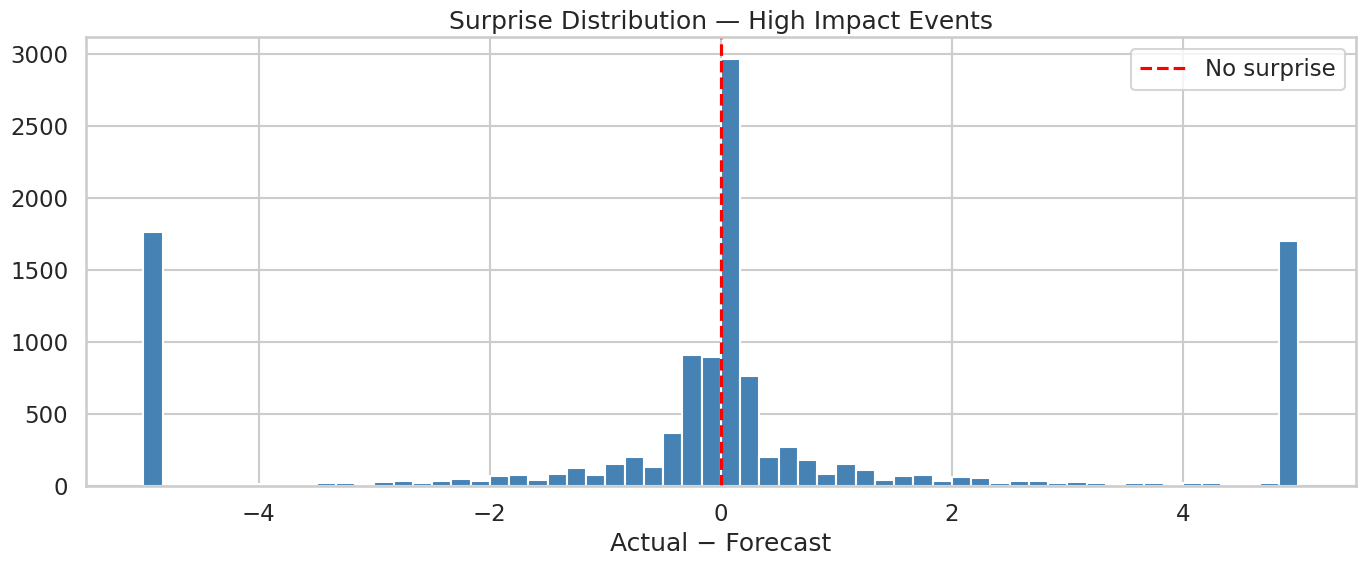

In [126]:
# ── Surprise distribution for High Impact events ───────────────────────────
high_impact = df[(df['is_high_impact'] == 1) & df['Surprise'].notna()]
high_impact['Surprise'].clip(-5, 5).hist(bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='No surprise')
plt.title('Surprise Distribution — High Impact Events')
plt.xlabel('Actual − Forecast')
plt.legend()
plt.tight_layout()
plt.show()

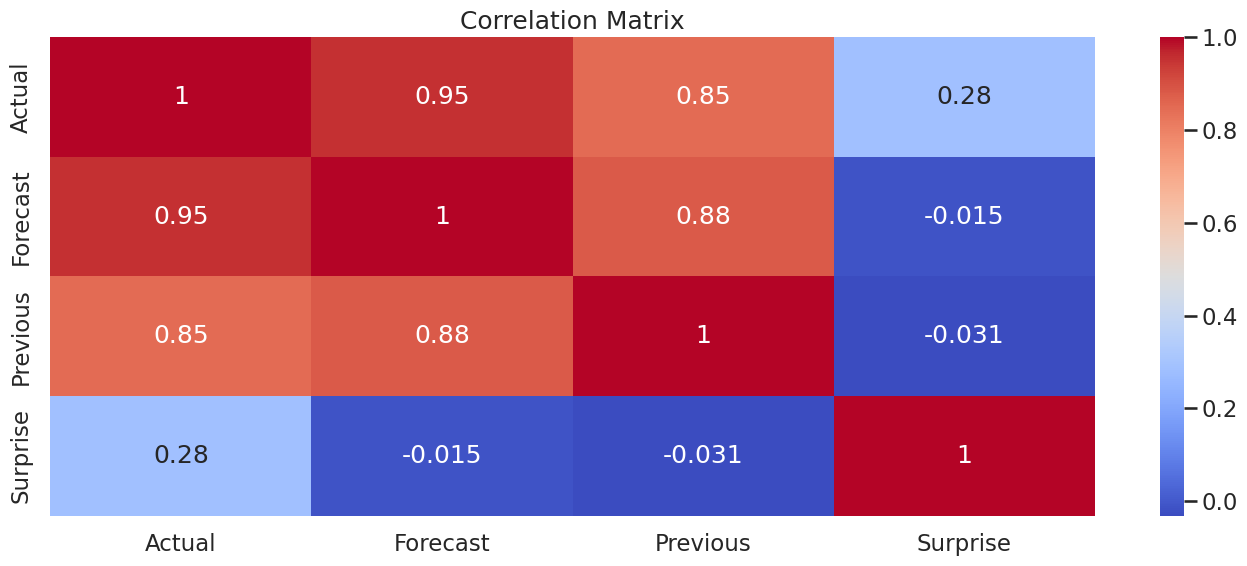

In [127]:
# ── Correlation heatmap ────────────────────────────────────────────────────
corr = df[['Actual','Forecast','Previous','Surprise']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

###Feature Engineering — Interpretation & Method Choice

**`Surprise = Actual − Forecast`** (most important feature)
- Markets price in the forecast in advance. The actual release only moves the market if it **deviates from the consensus**. A surprise of +0.5% on an unemployment rate is more meaningful than the absolute value of 4.5%.
- NaN propagates correctly: if either Actual or Forecast is missing, Surprise stays NaN — no fake zeros injected.

**`market_signal = surprise_direction × usual_effect`**
- Combines two extracted features into one actionable signal: +1 = bullish for currency, -1 = bearish, 0 = unknown/no forecast.
- Example: Unemployment Rate is lower than expected (negative surprise) AND `usual_effect = -1` (lower is good) → `market_signal = (-1) × (-1) = +1` (bullish for USD).

**`is_month_end` and `is_month_start`**
- Month-end brings institutional portfolio rebalancing flows that can amplify currency moves regardless of the event itself. This is domain knowledge from forex trading that a model cannot learn from the numeric data alone.

**Surprise histogram interpretation:**
- The distribution is centred on 0 (most events match forecasts closely) with fat tails — confirming that surprises are rare but exist, and they are the signal we most care about.

**Correlation matrix interpretation:**
- High correlation between Actual and Previous is expected — economic indicators are persistent month-to-month.
- Actual and Forecast also correlate highly — analysts are generally correct on direction even when they miss the magnitude.
- Surprise has low correlation with all three — confirming it captures information not already present in the raw values.

#11.Data Normalization

In [128]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
import pandas as pd

scale_cols = ['Actual', 'Forecast', 'Previous', 'Surprise']
df_temp = df[scale_cols].copy()

# ── Method 1: MinMaxScaler ────────────────────────────────────────────────
mm = MinMaxScaler()
df_minmax = pd.DataFrame(mm.fit_transform(df_temp), columns=scale_cols)

# ── Method 2: StandardScaler ──────────────────────────────────────────────
ss = StandardScaler()
df_standard = pd.DataFrame(ss.fit_transform(df_temp), columns=scale_cols)

# ── Method 3: RobustScaler (OUR CHOICE) ──────────────────────────────────
rb = RobustScaler()
df_robust = pd.DataFrame(rb.fit_transform(df_temp), columns=scale_cols)

# ── Comparison table ──────────────────────────────────────────────────────
stats = ['min', 'max', 'std', '50%', '25%', '75%']
for col in scale_cols:
    print(f"\n── {col} ──")
    print(pd.DataFrame({
        'Original'   : df_temp[col].describe(),
        'MinMax'     : df_minmax[col].describe(),
        'Standard'   : df_standard[col].describe(),
        'Robust'  : df_robust[col].describe(),
    }).loc[stats].round(4))

# ── Apply final scaler ────────────────────────────────────────────────────
scaler = RobustScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])


── Actual ──
         Original  MinMax  Standard        Robust
min -2.370000e+12  0.0000  -18.0624 -4.730539e+10
max  5.130000e+12  1.0000   38.8648  1.023952e+11
std  1.317482e+11  0.0176    1.0000  2.629705e+09
50%  2.000000e+00  0.3160   -0.0734  0.000000e+00
25%  0.000000e+00  0.3160   -0.0734 -3.990000e-02
75%  5.010000e+01  0.3160   -0.0734  9.601000e-01

── Forecast ──
         Original  MinMax  Standard        Robust
min -2.350000e+12  0.0000  -17.8522 -4.519231e+10
max  4.200000e+12  1.0000   31.7033  8.076923e+10
std  1.321763e+11  0.0202    1.0000  2.541851e+09
50%  1.900000e+00  0.3588   -0.0727  0.000000e+00
25%  2.000000e-01  0.3588   -0.0727 -3.270000e-02
75%  5.220000e+01  0.3588   -0.0727  9.673000e-01

── Previous ──
         Original  MinMax  Standard        Robust
min -2.340000e+12  0.0000  -17.8499 -4.670659e+10
max  5.130000e+12  1.0000   38.8983  1.023952e+11
std  1.316350e+11  0.0176    1.0000  2.627445e+09
50%  2.020000e+00  0.3133   -0.0734  0.000000e+00
25% 

### 📋 Data Normalization — Interpretation & Method Choice

**What the comparison reveals:**

The output exposes a critical problem in this dataset: extreme scale differences between events. `Surprise` ranges from −1.275 trillion to +3.633 trillion (Trade Balance in JPY), while most PMI or rate readings sit between −1 and +1. This single fact drives the entire method choice.

**❌ MinMaxScaler** compresses everything into [0, 1] based on the global min and max. The result is devastating: `25%`, `50%`, and `75%` for `Actual` all show **0.3160** — meaning 75% of all values are collapsed into an almost identical range near 0.316, completely indistinguishable from each other. The trillion-scale Trade Balance values own the entire [0, 1] range, leaving no room for meaningful separation of all other events.

**❌ StandardScaler** uses mean and standard deviation. The `Surprise` column after scaling shows a max of **106.25** and a min of **−37.28** — far from the expected [−3, +3] range of a well-standardised variable. This happens because the std is inflated by the trillion-scale outliers, making the scaled values misleading and unstable for any downstream model.

**✅ RobustScaler** uses the **median** and **IQR** instead of mean and std. Looking at the output:
- `median (50%) = 0.0` across all columns ✅ — the central tendency is correctly anchored at zero
- `25% and 75%` are symmetric and small (e.g. Actual: −0.0399 to +0.9601) ✅ — the bulk of the data is tightly and meaningfully scaled
- `min` and `max` remain large — but that is correct behaviour, not a flaw. Extreme values are preserved but no longer distort the central distribution that the model actually learns from.

**Conclusion:** MinMaxScaler is blind to outliers and collapses the useful signal into a single point. StandardScaler is distorted by the trillion-scale Trade Balance values. RobustScaler is the only method that produces a stable, meaningful scaling for this dataset — median anchored at 0, IQR normalized to 1, and outliers retained without poisoning the rest.

---
## 12. Final Feature Summary

| Feature | Source | Type | Why it's useful |
|---|---|---|---|
| `year`, `month`, `hour`, `day_of_week` | DateTime | Extracted | Temporal patterns |
| `is_month_end`, `is_month_start` | DateTime | Engineered | Rebalancing flow days |
| `Impact_Score` | Impact | Ordinal encoded | Event importance rank |
| `is_high_impact` | Impact | Engineered | Binary filter for market movers |
| `usual_effect` | Detail text | Extracted | Market direction of a beat |
| `has_actual`, `has_forecast`, `has_previous` | NaN flags | Extracted | Missingness as signal |
| `Actual`, `Forecast`, `Previous` | Parsed + clipped + scaled | Cleaned numeric | Core economic readings |
| `Surprise` | Actual − Forecast | Engineered | Market-moving deviation |
| `surprise_direction` | sign(Surprise) | Engineered | Beat or miss indicator |
| `market_signal` | direction × usual_effect | Engineered | Bullish/bearish signal |

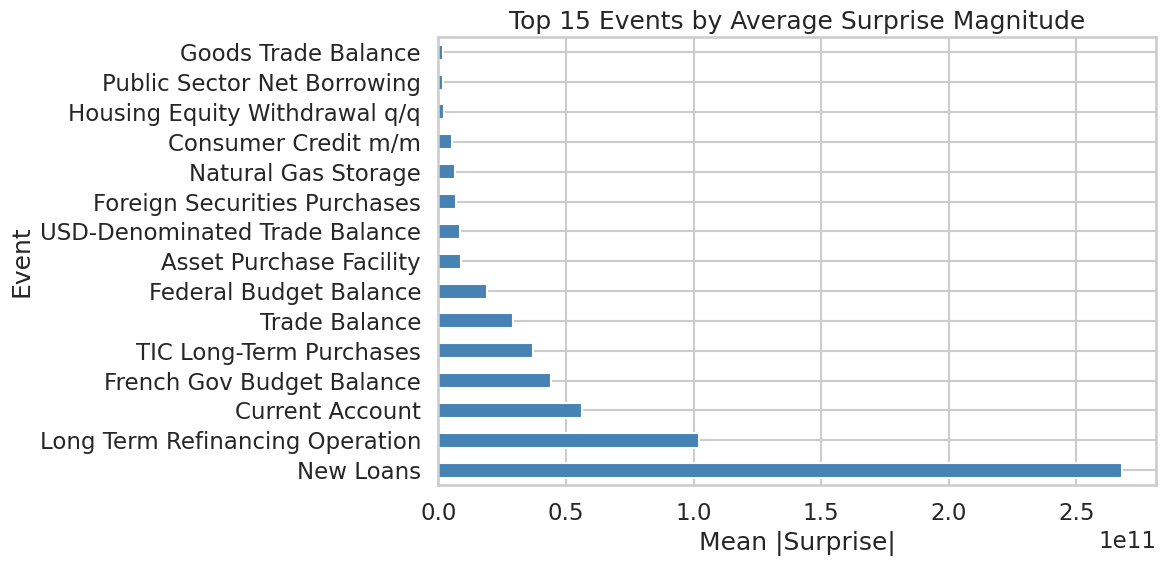

In [129]:
# Which events surprise the market the most?
df['Surprise_abs'] = df['Surprise'].abs()
top_surprise = (df.groupby('Event')['Surprise_abs']
                .mean()
                .dropna()
                .sort_values(ascending=False)
                .head(15))

top_surprise.plot(kind='barh', figsize=(12, 6), color='steelblue')
plt.title('Top 15 Events by Average Surprise Magnitude')
plt.xlabel('Mean |Surprise|')
plt.tight_layout()
plt.show()

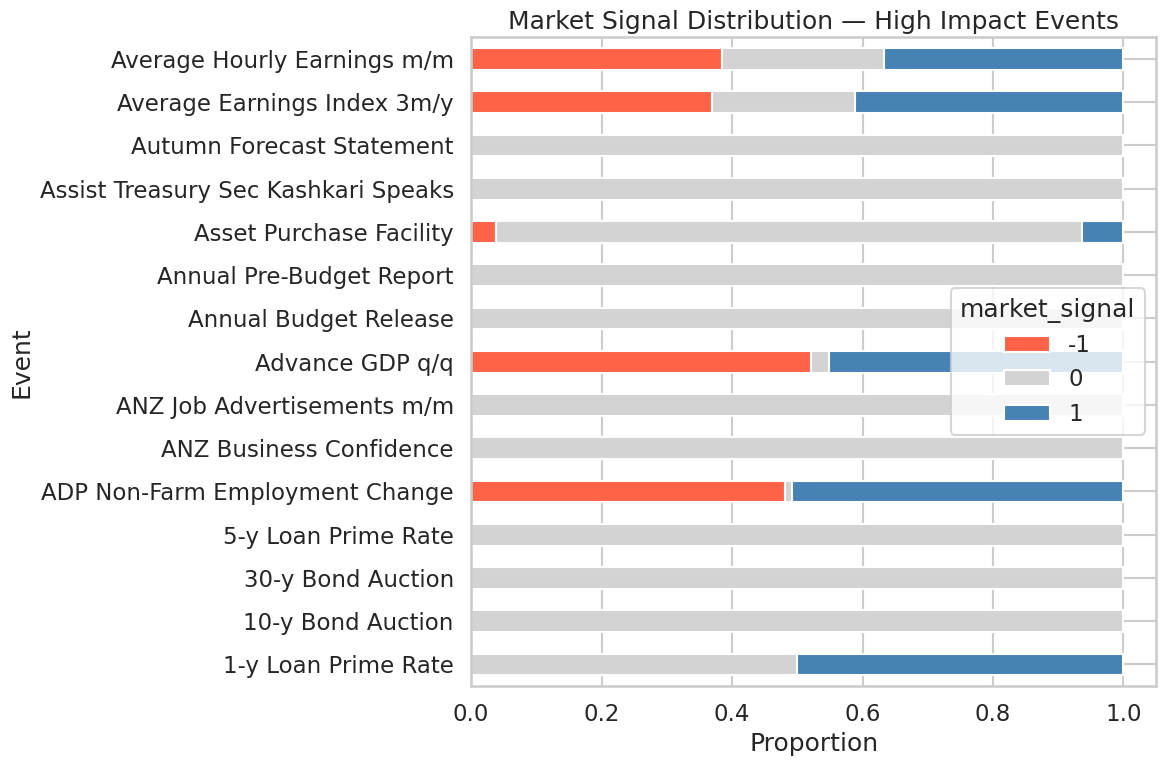

In [130]:
# For high impact events — how often bullish vs bearish?
signal_dist = (df[df['is_high_impact'] == 1]
               .groupby('Event')['market_signal']
               .value_counts(normalize=True)
               .unstack()
               .fillna(0))

signal_dist.head(15).plot(kind='barh', stacked=True,
                           color=['tomato','lightgray','steelblue'],
                           figsize=(12, 8))
plt.title('Market Signal Distribution — High Impact Events')
plt.xlabel('Proportion')
plt.tight_layout()
plt.show()

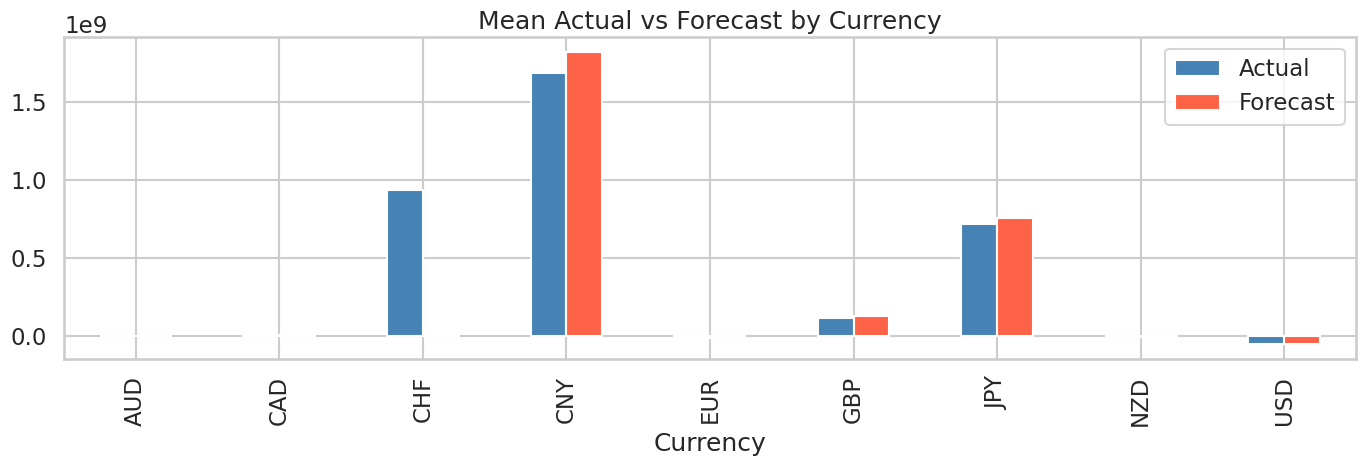

In [131]:
# How well do forecasts track actuals per currency?
df.groupby('Currency')[['Actual','Forecast']].mean().dropna().plot(
    kind='bar', figsize=(14, 5), color=['steelblue','tomato'])
plt.title('Mean Actual vs Forecast by Currency')
plt.tight_layout()
plt.show()